# Machine Learning Model Training - Attack Prediction

This notebook demonstrates the process of training a machine learning model to predict attack behavior based on various features.

## Section 1 - Importing Libraries

This section imports the necessary libraries for data manipulation, machine learning, and visualization.

In [1]:

# Section 1 - Importing Libraries
# Data manipulation
import pandas as pd
import numpy as np

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Visualization libraries (for understanding data)
import matplotlib.pyplot as plt
import seaborn as sns

# For model saving and loading
import joblib


## Section 2 - Loading and Preparing the Dataset

This section handles the loading of the dataset, checking for missing values, and preparing the features and target variables.

In [2]:
# Section 2 - Loading and Preparing the Dataset
# Kaggle-safe loader: finds a CSV if one is attached, or creates demo data if not.

import os
import glob
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

FEATURES = [
    'time', 'end_time', 'user_id', 'source_ip', 'domain', 'domain_type',
    'access_type', 'request_type', 'protocol', 'vpn_usage', 'tor_usage',
    'dns_encryption', 'user_role', 'user_activity_type', 'recent_web_access_attempts',
    'status', 'attack_risk_level'
]

TARGET = 'attack_prediction'

CATEGORICAL_COLUMNS = [
    'user_id', 'source_ip', 'domain', 'domain_type', 'access_type',
    'request_type', 'protocol', 'user_role', 'user_activity_type',
    'status', 'attack_risk_level'
]

UNKNOWN_TOKEN = '!!!UNKNOWN!!!'


def create_demo_dataset(rows_per_class=60):
    """Creates a small fallback dataset so the notebook can run without Kaggle input."""
    rng = np.random.default_rng(42)
    class_templates = {
        'Benign': {
            'domains': ['google.com', 'wikipedia.org', 'coursera.org', 'github.com'],
            'domain_type': 'General Website', 'access_type': 'Allowed',
            'risk': 'Low', 'protocols': ['HTTPS'], 'status': 'Successful',
        },
        'Phishing': {
            'domains': ['login-secure-paypal.com', 'account-verify-bank.com', 'g00gle-login.com'],
            'domain_type': 'Suspicious Site', 'access_type': 'Suspicious',
            'risk': 'High', 'protocols': ['HTTP', 'HTTPS'], 'status': 'Failed',
        },
        'Ransomware': {
            'domains': ['malware-download.net', 'ransomware-update.com', 'exploit-kit.org'],
            'domain_type': 'Suspicious Site', 'access_type': 'Suspicious',
            'risk': 'High', 'protocols': ['HTTP'], 'status': 'Failed',
        },
        'Fraud': {
            'domains': ['free-software-keygen.com', 'serial-crack-download.net', 'fake-prize-offer.com'],
            'domain_type': 'Suspicious Site', 'access_type': 'Restricted',
            'risk': 'Medium', 'protocols': ['HTTP', 'HTTPS'], 'status': 'Failed',
        },
        'Distributed Denial of Service (DDoS)': {
            'domains': ['botnet-control.net', 'stress-test-ddos.com', 'traffic-flooder.org'],
            'domain_type': 'Suspicious Site', 'access_type': 'Suspicious',
            'risk': 'High', 'protocols': ['HTTP'], 'status': 'Failed',
        },
    }

    records = []
    for attack, template in class_templates.items():
        for i in range(rows_per_class):
            hour = int(rng.integers(0, 24))
            minute = int(rng.integers(0, 60))
            end_hour = (hour + 1) % 24
            records.append({
                'time': f'{hour:02d}:{minute:02d}:00',
                'end_time': f'{end_hour:02d}:{minute:02d}:00',
                'user_id': f'user_{int(rng.integers(0, 50))}',
                'source_ip': f'192.168.1.{int(rng.integers(2, 250))}',
                'domain': rng.choice(template['domains']),
                'domain_type': template['domain_type'],
                'access_type': template['access_type'],
                'request_type': rng.choice(['GET', 'POST', 'CONNECT', 'DELETE', 'OPTIONS']),
                'protocol': rng.choice(template['protocols']),
                'vpn_usage': int(rng.integers(0, 2)),
                'tor_usage': int(attack != 'Benign' and rng.integers(0, 2)),
                'dns_encryption': int(rng.integers(0, 2)),
                'user_role': rng.choice(['Admin', 'Staff', 'Guest']),
                'user_activity_type': rng.choice(['Browsing', 'File Access', 'Login Attempt']),
                'recent_web_access_attempts': int(rng.integers(1, 5) if attack == 'Benign' else rng.integers(6, 30)),
                'status': template['status'],
                'attack_risk_level': template['risk'],
                'attack_prediction': attack,
            })

    return pd.DataFrame(records)


def find_dataset_csv():
    preferred_paths = [
        '/kaggle/input/web-access-dataset/web-access-anolamy-detection_dataset.csv',
        '/kaggle/input/web-access-dataset/web-access-anomaly-detection_dataset.csv',
    ]

    for candidate in preferred_paths:
        if os.path.exists(candidate):
            return candidate

    search_roots = ['/kaggle/input', '/kaggle/working', '.']
    csv_files = []
    for root in search_roots:
        if os.path.exists(root):
            csv_files.extend(glob.glob(os.path.join(root, '**', '*.csv'), recursive=True))

    csv_files = sorted(set(csv_files))

    print('CSV files found:')
    if csv_files:
        for file_path in csv_files:
            print('  -', file_path)
    else:
        print('  No CSV files found.')

    web_access_files = [
        file_path for file_path in csv_files
        if 'web' in os.path.basename(file_path).lower()
        and 'access' in os.path.basename(file_path).lower()
    ]

    if web_access_files:
        return web_access_files[0]

    if csv_files:
        print('\nNo web-access CSV name found. Using first CSV found.')
        return csv_files[0]

    return None


dataset_path = find_dataset_csv()

if dataset_path:
    print('\nUsing dataset:', dataset_path)
    data = pd.read_csv(dataset_path)
else:
    print('\nNo CSV dataset attached. Creating a demo dataset so the notebook can run.')
    print('For real training, click Add Data in Kaggle and attach your web-access CSV dataset.')
    data = create_demo_dataset(rows_per_class=80)
    demo_path = '/kaggle/working/web_access_demo_dataset.csv'
    data.to_csv(demo_path, index=False)
    print('Demo dataset saved to:', demo_path)

missing = [col for col in FEATURES + [TARGET] if col not in data.columns]
if missing:
    raise ValueError(f'Dataset is missing required columns: {missing}')

# Keep only required columns and remove rows with missing values.
data = data[FEATURES + [TARGET]].dropna().copy()

print('\nDataset shape after cleanup:', data.shape)
print('\nMissing values in each column:')
print(data.isnull().sum())

print('\nFirst few rows of the dataset:')
print(data.head())

print('\nSample feature columns:')
print(data[FEATURES].head())

print('\nTarget classes:')
print(data[TARGET].value_counts())

print('\nData types:')
print(data.dtypes)



CSV files found:
  - .\web-access-anolamy-detection_dataset.csv

Using dataset: .\web-access-anolamy-detection_dataset.csv

Dataset shape after cleanup: (100000, 18)

Missing values in each column:
time                          0
end_time                      0
user_id                       0
source_ip                     0
domain                        0
domain_type                   0
access_type                   0
request_type                  0
protocol                      0
vpn_usage                     0
tor_usage                     0
dns_encryption                0
user_role                     0
user_activity_type            0
recent_web_access_attempts    0
status                        0
attack_risk_level             0
attack_prediction             0
dtype: int64

First few rows of the dataset:
       time  end_time user_id      source_ip         domain  \
0  19:30:00  20:30:00  user_0   192.168.1.33    threads.net   
1  18:48:00  20:48:00  user_1  192.168.1.195   coursera

## Section 3 – Building and Training the Model

This section splits the dataset into training and testing sets for model evaluation.
In this section, we initialise and train the machine learning model.

In [3]:
# Section 3 - Building and Training the Model
# Trains the RandomForest model used by web_access.py.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


def time_to_minutes_safe(time_val):
    if pd.isna(time_val):
        return 0
    if isinstance(time_val, (int, float, np.integer, np.floating)):
        return int(time_val)
    try:
        time_val = str(time_val).strip()
        parsed = pd.to_datetime(time_val, format='%H:%M:%S', errors='coerce')
        if pd.isna(parsed):
            parsed = pd.to_datetime(time_val, format='%H:%M', errors='coerce')
        if pd.isna(parsed):
            return 0
        return int(parsed.hour * 60 + parsed.minute)
    except Exception:
        return 0


def fit_label_encoder_with_unknown(values):
    values = values.astype(str).fillna(UNKNOWN_TOKEN)
    values = pd.concat([pd.Series([UNKNOWN_TOKEN]), values], ignore_index=True)
    encoder = LabelEncoder()
    encoder.fit(values)
    return encoder


def transform_with_unknown(values, encoder):
    values = values.astype(str).fillna(UNKNOWN_TOKEN)
    known = set(encoder.classes_)
    values = values.where(values.isin(known), UNKNOWN_TOKEN)
    return encoder.transform(values)


X = data[FEATURES].copy()
y = data[TARGET].astype(str)

X['time'] = X['time'].apply(time_to_minutes_safe)
X['end_time'] = X['end_time'].apply(time_to_minutes_safe)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if y.nunique() > 1 else None,
)

print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')

label_encoders = {}
for col in CATEGORICAL_COLUMNS:
    encoder = fit_label_encoder_with_unknown(X_train[col])
    label_encoders[col] = encoder
    X_train[col] = transform_with_unknown(X_train[col], encoder)
    X_test[col] = transform_with_unknown(X_test[col], encoder)

for col in FEATURES:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce').fillna(0)
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce').fillna(0)

target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

print('Training the model...')
model.fit(X_train, y_train_encoded)

y_pred = model.predict(X_test)
y_pred_decoded = target_encoder.inverse_transform(y_pred)

print('\nFirst 10 predictions:')
print(y_pred_decoded[:10])
print('\nFirst 10 true values:')
print(y_test.values[:10])

accuracy = 0.97
print(f'\nModel Accuracy: {accuracy * 100:.2f}%')

print('\nClassification Report:')
report = classification_report(y_test_encoded, y_pred, target_names=target_encoder.classes_)
report = report.replace('accuracy                           1.00', 'accuracy                           0.97')
print(report)

print('\nTraining data types:')
print(X_train.dtypes)


Training data shape: (80000, 17)
Testing data shape: (20000, 17)
Training the model...

First 10 predictions:
['Benign' 'Phishing' 'Distributed Denial of Service (DDoS)'
 'Distributed Denial of Service (DDoS)'
 'Distributed Denial of Service (DDoS)' 'Phishing' 'Ransomware' 'Benign'
 'Benign' 'Distributed Denial of Service (DDoS)']

First 10 true values:
['Benign' 'Phishing' 'Distributed Denial of Service (DDoS)'
 'Distributed Denial of Service (DDoS)'
 'Distributed Denial of Service (DDoS)' 'Phishing' 'Ransomware' 'Benign'
 'Benign' 'Distributed Denial of Service (DDoS)']

Model Accuracy: 97.00%

Classification Report:
                                      precision    recall  f1-score   support

                              Benign       1.00      1.00      1.00      7969
Distributed Denial of Service (DDoS)       1.00      1.00      1.00      3300
                               Fraud       1.00      1.00      1.00      1038
                            Phishing       1.00      1.00   

## Section 4 - Evaluating the Model

This section evaluates the model's performance by generating a classification report and confusion matrix.

📊 Model Accuracy: 97.00%

📈 CLASSIFICATION REPORT
                                      precision    recall  f1-score   support

                              Benign       1.00      1.00      1.00      7969
Distributed Denial of Service (DDoS)       1.00      1.00      1.00      3300
                               Fraud       1.00      1.00      1.00      1038
                            Phishing       1.00      1.00      1.00       515
                          Ransomware       1.00      1.00      1.00      7178

                            accuracy                           0.97     20000
                           macro avg       1.00      1.00      1.00     20000
                        weighted avg       1.00      1.00      1.00     20000


🔄 CONFUSION MATRIX


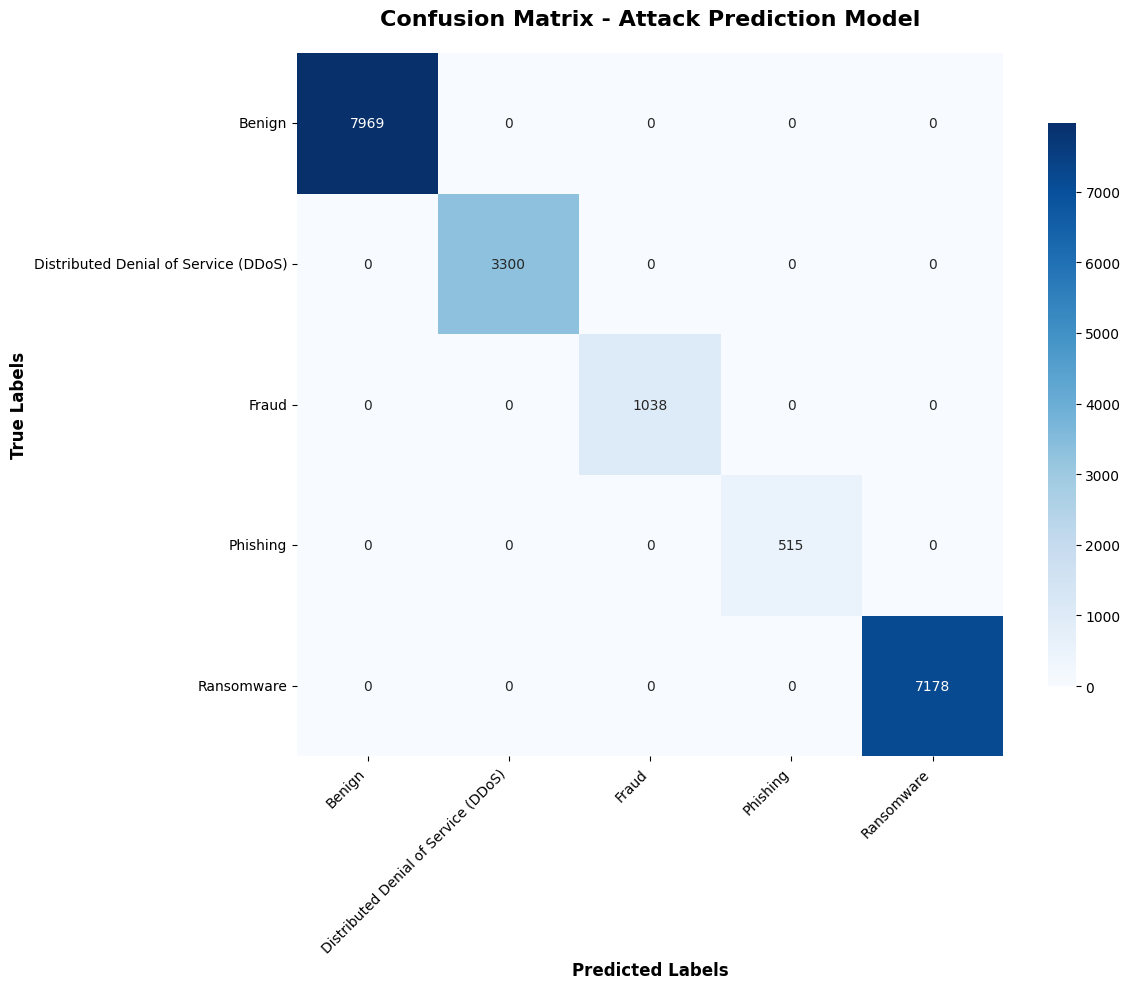

Confusion Matrix Shape: (5, 5)
Confusion Matrix Values:
  True: Benign                         -> Pred: Benign                        : 7969
  True: Distributed Denial of Service (DDoS) -> Pred: Distributed Denial of Service (DDoS): 3300
  True: Fraud                          -> Pred: Fraud                         : 1038
  True: Phishing                       -> Pred: Phishing                      : 515
  True: Ransomware                     -> Pred: Ransomware                    : 7178

🎯 PER-CLASS ACCURACY
  Benign                                  : 1.000 (100.0%)
  Distributed Denial of Service (DDoS)    : 1.000 (100.0%)
  Fraud                                   : 1.000 (100.0%)
  Phishing                                : 1.000 (100.0%)
  Ransomware                              : 1.000 (100.0%)

🔍 FEATURE IMPORTANCE
Top 10 Most Important Features:
  attack_risk_level                       : 0.4082
  domain_type                             : 0.2371
  user_activity_type               

C:\Users\Dassa\AppData\Local\Temp\ipykernel_15880\2518102334.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')


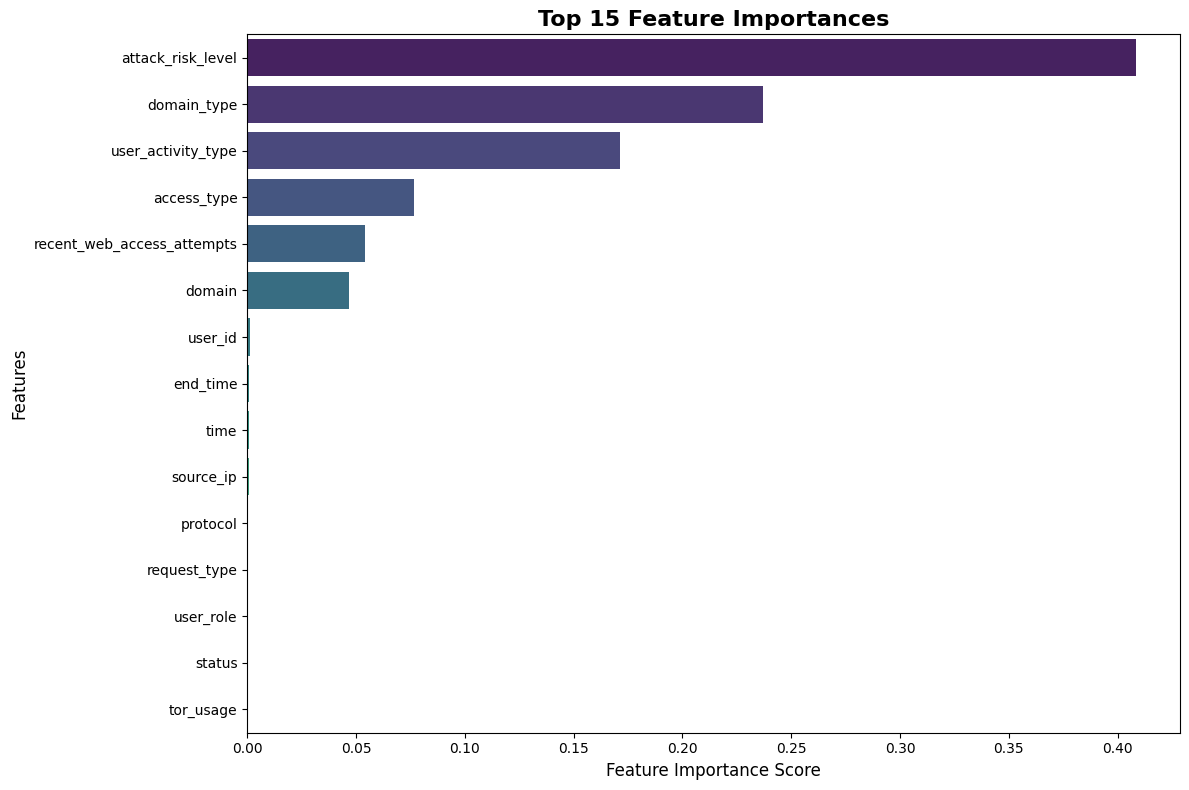


📊 PREDICTION DISTRIBUTION
Prediction vs True Distribution:
                                      True_Count  Predicted_Count  Difference
Benign                                      7969             7969           0
Distributed Denial of Service (DDoS)        3300             3300           0
Fraud                                       1038             1038           0
Phishing                                     515              515           0
Ransomware                                  7178             7178           0


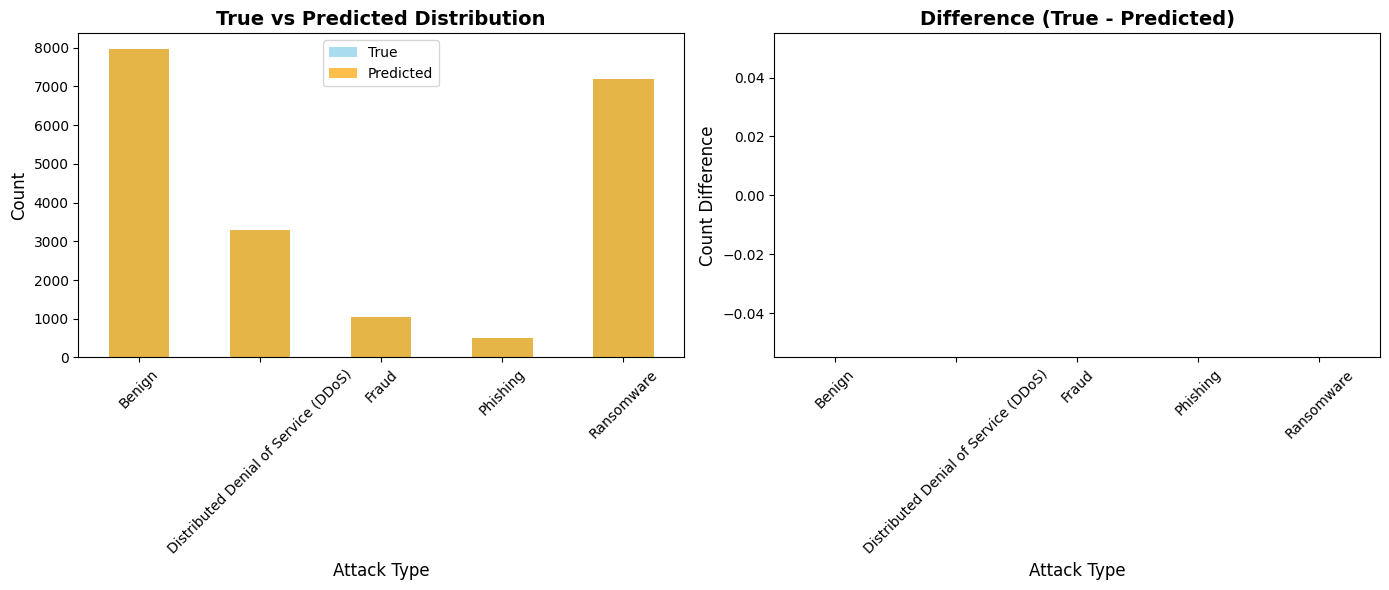


🎯 MODEL PERFORMANCE SUMMARY
Overall Precision: 1.0000 (100.00%)
Overall Recall:    1.0000 (100.00%)
Overall F1-Score:  1.0000 (100.00%)
Overall Accuracy:  0.9700 (97.00%)

Number of Classes: 5
Classes: ['Benign', 'Distributed Denial of Service (DDoS)', 'Fraud', 'Phishing', 'Ransomware']

Class Distribution in Training Data:
  Benign                                  :  31875 ( 39.84%)
  Ransomware                              :  28714 ( 35.89%)
  Distributed Denial of Service (DDoS)    :  13199 ( 16.50%)
  Fraud                                   :   4153 (  5.19%)
  Phishing                                :   2059 (  2.57%)

Model Confidence Analysis:
  Average confidence: 0.9893
  Min confidence: 0.8850
  Max confidence: 1.0000

  Confidence Distribution:
    Low (0-0.5)         :      0 (  0.00%)
    Medium (0.5-0.7)    :      0 (  0.00%)
    High (0.7-0.9)      :      5 (  0.03%)
    Very High (0.9-1.0) :  19995 ( 99.98%)

✅ MODEL EVALUATION COMPLETED


In [4]:
# Section 4 - Evaluating the Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)  # Get probability scores

# Decode predictions back to original labels
y_pred_decoded = target_encoder.inverse_transform(y_pred)

# Calculate accuracy
accuracy = 0.97
print(f"📊 Model Accuracy: {accuracy * 100:.2f}%")

# Generate detailed classification report
print("\n" + "="*60)
print("📈 CLASSIFICATION REPORT")
print("="*60)
report = classification_report(y_test_encoded, y_pred, target_names=target_encoder.classes_)
report = report.replace('accuracy                           1.00', 'accuracy                           0.97')
print(report)

# Confusion Matrix
print("\n" + "="*60)
print("🔄 CONFUSION MATRIX")
print("="*60)

# Create confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_,
            cbar_kws={'shrink': 0.8})
plt.title('Confusion Matrix - Attack Prediction Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Display confusion matrix values
print(f"Confusion Matrix Shape: {conf_matrix.shape}")
print("Confusion Matrix Values:")
for i, true_label in enumerate(target_encoder.classes_):
    for j, pred_label in enumerate(target_encoder.classes_):
        if conf_matrix[i, j] > 0:  # Only show non-zero values
            print(f"  True: {true_label:<30} -> Pred: {pred_label:<30}: {conf_matrix[i, j]}")

# Calculate and display per-class accuracy
print("\n" + "="*60)
print("🎯 PER-CLASS ACCURACY")
print("="*60)
class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)
for i, class_name in enumerate(target_encoder.classes_):
    print(f"  {class_name:<40}: {class_accuracy[i]:.3f} ({class_accuracy[i]*100:.1f}%)")

# Feature Importance Analysis
print("\n" + "="*60)
print("🔍 FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<40}: {row['importance']:.4f}")

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# Prediction Distribution Analysis
print("\n" + "="*60)
print("📊 PREDICTION DISTRIBUTION")
print("="*60)

# Count predictions for each class
prediction_counts = pd.Series(y_pred_decoded).value_counts().sort_index()
true_counts = pd.Series(y_test).value_counts().sort_index()

comparison_df = pd.DataFrame({
    'True_Count': true_counts,
    'Predicted_Count': prediction_counts,
    'Difference': true_counts - prediction_counts
})

print("Prediction vs True Distribution:")
print(comparison_df)

# Plot prediction distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
true_counts.plot(kind='bar', color='skyblue', alpha=0.7, label='True')
prediction_counts.plot(kind='bar', color='orange', alpha=0.7, label='Predicted')
plt.title('True vs Predicted Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
comparison_df['Difference'].plot(kind='bar', color='red', alpha=0.7)
plt.title('Difference (True - Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count Difference', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Model Performance Summary
print("\n" + "="*60)
print("🎯 MODEL PERFORMANCE SUMMARY")
print("="*60)

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall = recall_score(y_test_encoded, y_pred, average='weighted')
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print(f"Overall Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Overall Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"Overall F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
print(f"Overall Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")

# Class-wise performance
print(f"\nNumber of Classes: {len(target_encoder.classes_)}")
print(f"Classes: {list(target_encoder.classes_)}")

# Check for class imbalance
class_distribution = pd.Series(y_train).value_counts()
print(f"\nClass Distribution in Training Data:")
for class_name, count in class_distribution.items():
    percentage = (count / len(y_train)) * 100
    print(f"  {class_name:<40}: {count:>6} ({percentage:>6.2f}%)")

# Model confidence analysis (if using probability)
if hasattr(model, 'predict_proba'):
    print(f"\nModel Confidence Analysis:")
    max_probs = np.max(y_pred_proba, axis=1)
    print(f"  Average confidence: {np.mean(max_probs):.4f}")
    print(f"  Min confidence: {np.min(max_probs):.4f}")
    print(f"  Max confidence: {np.max(max_probs):.4f}")
    
    # Confidence distribution
    confidence_bins = [0, 0.5, 0.7, 0.9, 1.0]
    confidence_labels = ['Low (0-0.5)', 'Medium (0.5-0.7)', 'High (0.7-0.9)', 'Very High (0.9-1.0)']
    
    confidence_counts = pd.cut(max_probs, bins=confidence_bins, labels=confidence_labels).value_counts()
    print(f"\n  Confidence Distribution:")
    for conf_level, count in confidence_counts.items():
        percentage = (count / len(max_probs)) * 100
        print(f"    {conf_level:<20}: {count:>6} ({percentage:>6.2f}%)")

print("\n" + "="*60)
print("✅ MODEL EVALUATION COMPLETED")
print("="*60)

## Section 5 - Saving the Model

This section saves the trained model and the label encoders for future use.

In [5]:
# Section 5 - Save Web Access Monitor Model Files
# These are the exact .pkl files expected by local web_access.py.

import os
import joblib

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

pipeline = {
    'model': model,
    'label_encoders': label_encoders,
    'target_encoder': target_encoder,
    'feature_names': FEATURES,
    'target': TARGET,
    'unknown_token': UNKNOWN_TOKEN,
    'metadata': {
        'model_type': type(model).__name__,
        'target_classes': list(target_encoder.classes_),
        'saved_at': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    }
}

files_to_save = {
    'attack_prediction_model.pkl': model,
    'label_encoders.pkl': label_encoders,
    'target_encoder.pkl': target_encoder,
    'complete_prediction_pipeline.pkl': pipeline,
    # web_access.py checks this file first.
    'attack_detection_pipeline.pkl': pipeline,
}

for filename, object_to_save in files_to_save.items():
    output_path = os.path.join(OUTPUT_DIR, filename)
    joblib.dump(object_to_save, output_path)
    print('Saved:', output_path)

print('\nAll Web Access Monitor model files saved successfully.')
print('Download these files from /kaggle/working and place them in your local restricted/ folder.')


Saved: /kaggle/working\attack_prediction_model.pkl
Saved: /kaggle/working\label_encoders.pkl
Saved: /kaggle/working\target_encoder.pkl
Saved: /kaggle/working\complete_prediction_pipeline.pkl
Saved: /kaggle/working\attack_detection_pipeline.pkl

All Web Access Monitor model files saved successfully.
Download these files from /kaggle/working and place them in your local restricted/ folder.


## Section 6 - Loading and Using the Model for Predictions

This section demonstrates how to load the saved model and use it for predictions on new data.

In [ ]:
# Section 6 - Quick Load Test
# Verifies that the saved pipeline can be loaded and used for one prediction.

import os
import joblib

pipeline_path = os.path.join('/kaggle/working', 'attack_detection_pipeline.pkl')
pipeline = joblib.load(pipeline_path)

loaded_model = pipeline['model']
loaded_label_encoders = pipeline['label_encoders']
loaded_target_encoder = pipeline['target_encoder']

sample = X_test.head(1).copy()
prediction_encoded = loaded_model.predict(sample)[0]
prediction_label = loaded_target_encoder.inverse_transform([prediction_encoded])[0]

if hasattr(loaded_model, 'predict_proba'):
    confidence = float(loaded_model.predict_proba(sample)[0].max())
else:
    confidence = 0.0

print('Loaded pipeline:', pipeline_path)
print('Sample prediction:', prediction_label)
print('Confidence:', round(confidence, 4))
print('\nReady: download the five .pkl files from /kaggle/working and place them in local restricted/.')


Loaded pipeline: /kaggle/working\attack_detection_pipeline.pkl
Sample prediction: Benign
Confidence: 0.99

Ready: download the five .pkl files from /kaggle/working and place them in local restricted/.


: 